In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2 as cv

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


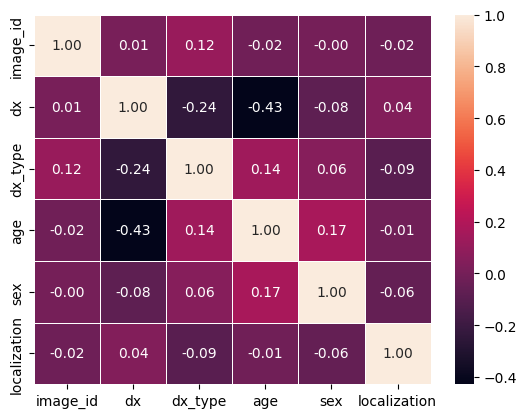

In [35]:
from sklearn import preprocessing
meta = pd.read_csv('../metadata.csv')
meta = meta.dropna()
print(meta.head())
le = preprocessing.LabelEncoder()
meta['image_id']= preprocessing.LabelEncoder().fit_transform(meta['image_id']) 
meta['dx']= le.fit_transform(meta['dx']) 
meta['dx_type']= preprocessing.LabelEncoder().fit_transform(meta['dx_type']) 
meta['sex']= preprocessing.LabelEncoder().fit_transform(meta['sex'])
meta['localization']= preprocessing.LabelEncoder().fit_transform(meta['localization'])
meta = meta.drop(['lesion_id'], axis=1)
corr = meta.corr()
sns.heatmap(corr,annot=True,fmt=".2f", linewidth=.5)
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
labels = meta['dx']
train = meta.drop(['image_id','dx'],axis = 1)
train = np.array(train)
labels = np.array(labels)
x_train, x_test, y_train, y_test = train_test_split(train, labels, test_size=0.2, random_state=42)

In [31]:
# x_train = tf.keras.utils.normalize(x_train, axis=1)
# x_test = tf.keras.utils.normalize(x_test, axis=1)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)

RandomForestClassifier()

In [33]:
# evaluate
y_pred = clf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy: {:.2f}'.format(accuracy))

correct = [0]*7
total = [0]*7
for i in range(y_test.shape[0]):
    if y_test[i] == y_pred[i]:
        correct[y_test[i]] += 1
    total[y_test[i]] += 1

print('Accuracy per class:')
for i in range(7):
    print('\t{}: {:.2f}'.format(le.inverse_transform([i])[0], correct[i]/total[i]*100))

Accuracy: 0.73
Accuracy per class:
	akiec: 9.23
	bcc: 20.88
	bkl: 40.00
	df: 41.38
	mel: 29.33
	nv: 94.46
	vasc: 14.29


In [34]:
# random check
import random
y_random = [random.randint(0,6) for i in range(len(y_test))]
accuracy = accuracy_score(y_test, y_random)

print('Accuracy: {:.2f}'.format(accuracy))
correct = [0]*7
total = [0]*7
for i in range(y_test.shape[0]):
    if y_test[i] == y_random[i]:
        correct[y_test[i]] += 1
    total[y_test[i]] += 1

print('Accuracy per class:')
for i in range(7):
    print('\t{}: {:.2f}'.format(le.inverse_transform([i])[0], correct[i]/total[i]*100))

Accuracy: 0.14
Accuracy per class:
	akiec: 16.92
	bcc: 7.69
	bkl: 13.33
	df: 17.24
	mel: 17.78
	nv: 13.85
	vasc: 14.29
